In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

Loading data

In [2]:
telco_churn = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
telco_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
telco_churn.shape

(7043, 21)

In [4]:
telco_churn.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity  \
0     7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No   
1     5575-GNVDE    Male              0      No         No      34          Yes                No             DSL            Yes   
2     3668-QPYBK    Male              0      No         No       2          Yes                No             DSL            Yes   
3     7795-CFOCW    Male              0      No         No      45           No  No phone service             DSL            Yes   
4     9237-HQITU  Female              0      No         No       2          Yes                No     Fiber optic             No   
...          ...     ...            ...     ...        ...     ...          ...               ...             ...            ...   
7038  6840-RESVB    Male              0     

Standardize column names

In [5]:
telco_churn.columns = (telco_churn.columns.str.lower().str.strip().str.replace(' ', '_').str.replace('-', '_'))
telco_churn.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract',
       'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

Target and basic distribution

In [6]:
Target = 'churn'
telco_churn[Target].value_counts(dropna=False)

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
churn_rate = (telco_churn[Target].astype(str).str.lower().isin(['yes', '1', 'true'])).mean()
print(f'Churn rate (approx if yes/no) : {churn_rate:.3f}')

Churn rate (approx if yes/no) : 0.265


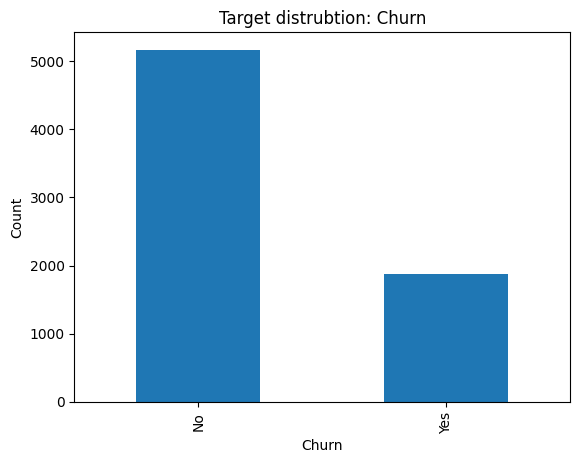

In [8]:
plt.figure()
telco_churn[Target].value_counts().plot(kind = 'bar')
plt.title('Target distrubtion: Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [10]:
missing = telco_churn.isna().sum().sort_values(ascending =False)
missing_pct = (missing/ len(telco_churn)).sort_values(ascending=False)

missing_report = pd.DataFrame({
    'missing' : missing,
    'missing_pct' : (missing_pct * 100).round(2)
})

display(missing_report[missing_report['missing']>0])

,missing,missing_pct


In [11]:
id_col = 'customerid' if 'customerid' in telco_churn.columns else None
if id_col:
    dup_count = telco_churn.duplicated(subset = [id_col]).sum()
    print(f'Duplicated {id_col} : {dup_count}')
else:
    print('No customerid colum found.')

Duplicated customerid : 0


Data Quality Check Summary
- No missing values were detected across all columns.
- No duplicate customer IDs were found.
- The dataset is clean and ready for exploratory analysis and modeling.

Fixing common Telco issue: TotalCharges numeric

In [12]:
if 'totalcharges' in telco_churn :
    telco_churn['totalcharges'] = pd.to_numeric(telco_churn['totalcharges'].astype(str).str.strip(), errors ='coerce')
    print('totalcharges coereced to numeric. Missing now: ', telco_churn['totalcharges'].isna().sum())
    

totalcharges coereced to numeric. Missing now:  11


In [13]:
telco_churn.loc[telco_churn["tenure"] == 0, "totalcharges"] = 0


TotalCharges Data Type Fix
- 'totalcharges' was converted from object to numeric.
- 11 values were coerced to NaN.
- These rows correspond to customers with 'tenure = 0' and represent new customers with no accumulated charges.
- No rows were dropped at this stage.

Separate numeric vs categorical

In [14]:
num_cols = telco_churn.select_dtypes(include=['number']).columns.tolist()
cat_cols = [c for c in telco_churn if c not in num_cols]

print('Numeric: ', num_cols)
print('categorical: ', cat_cols[:20], '...' if len(cat_cols)> 20 else'')

Numeric:  ['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges']
categorical:  ['customerid', 'gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'churn'] 


Numeric summary + churn comparison

In [16]:
display(telco_churn[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
seniorcitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
monthlycharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
totalcharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


Create churn_flag

In [18]:
telco_churn['churn_flag'] = telco_churn['churn'].map({'Yes' : 1, 'No': 0})

telco_churn['churn_flag'].value_counts()

churn_flag
0    5174
1    1869
Name: count, dtype: int64

In [19]:
telco_churn['churn_flag'].mean()

np.float64(0.2653698707936959)

Churn vs numeric features

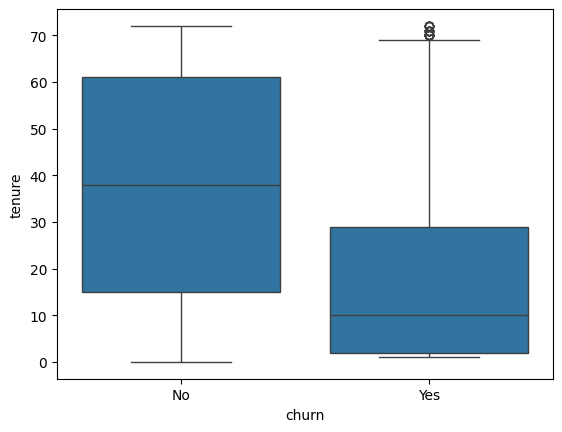

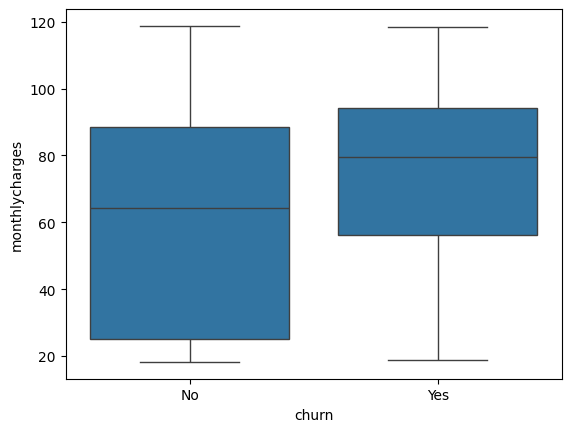

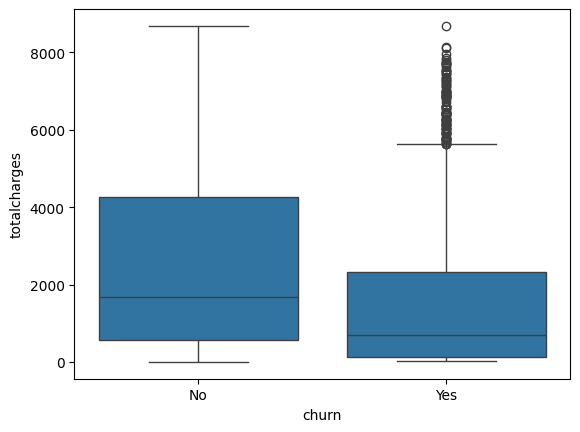

In [30]:
for c in ['tenure','monthlycharges', 'totalcharges'] :
    plt.figure()
    sns.boxplot( x='churn', y=c, data = telco_churn)
    plt.show()

Exploratory analysis of numeric features reveals a strong relationship between customer tenure, monthly charges, and total charges with churn behavior.

Customers who churn tend to have significantly shorter tenure, indicating that churn risk is highest during the early stages of the customer lifecycle. In contrast, customers who remain with the company show much longer and more varied tenure, suggesting increased loyalty over time.

Churned customers also exhibit higher monthly charges on average compared to non-churned customers. This suggests that higher recurring costs may contribute to dissatisfaction, especially among newer customers who have not yet built long-term commitment.

As a result of shorter tenure, customers who churn accumulate lower total charges, while retained customers generate substantially higher lifetime value. Although some high–total charge outliers exist among churned customers, the overall trend indicates that long-term retention is a key driver of customer value.

Categorical Features vs Churn

In [33]:
def churn_rate_by(col):
    return (
        telco_churn
        .groupby(col)["churn_flag"]
        .agg(churn_rate="mean", count="size")
        .sort_values("churn_rate", ascending=False)
    )

In [34]:
churn_rate_by('contract')

,churn_rate,count
contract,,
Month-to-month,0.427097,3875
One year,0.112695,1473
Two year,0.028319,1695


In [35]:
churn_rate_by("internetservice")

,churn_rate,count
internetservice,,
Fiber optic,0.418928,3096
DSL,0.189591,2421
No,0.074050,1526


In [36]:
churn_rate_by("paymentmethod")

,churn_rate,count
paymentmethod,,
Electronic check,0.452854,2365
Mailed check,0.191067,1612
Bank transfer (automatic),0.167098,1544
Credit card (automatic),0.152431,1522


In [37]:
churn_rate_by("paperlessbilling")

,churn_rate,count
paperlessbilling,,
Yes,0.335651,4171
No,0.163301,2872


In [38]:
churn_rate_by("seniorcitizen")

,churn_rate,count
seniorcitizen,,
1,0.416813,1142
0,0.236062,5901


Contract type

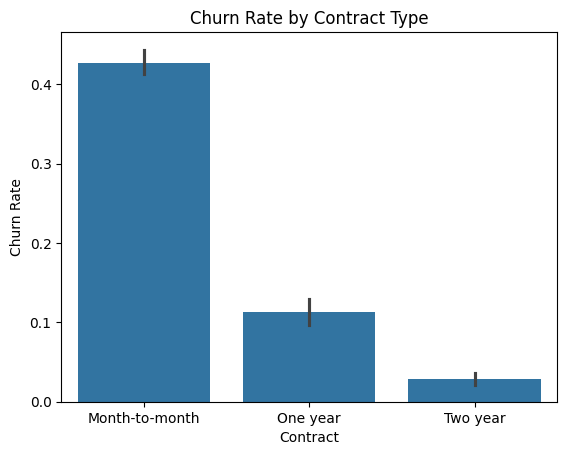

In [40]:
plt.figure()
sns.barplot(x="contract", y="churn_flag",data=telco_churn,estimator=np.mean)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract")
plt.show()

Payment method

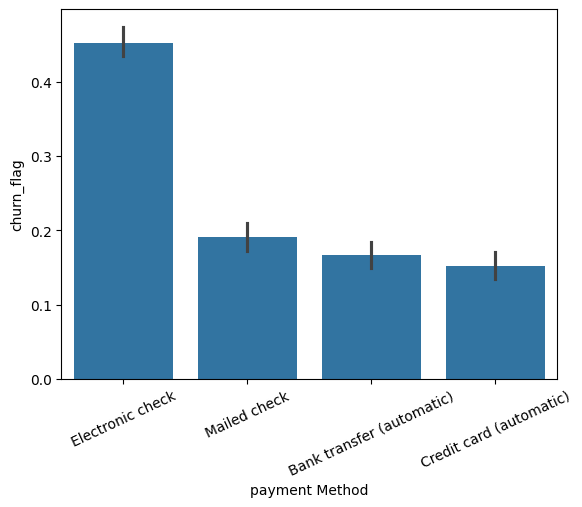

In [ ]:
plt.figure()
sns.barplot(x='paymentmethod', y='churn_flag', data=telco_churn, estimator=np.mean)
plt.title('ChurnRate by payment Method')
plt.xlabel('payment Method')
plt.xticks(rotation=25)
plt.show()

Categorical feature analysis shows that customer churn is strongly influenced by contract structure, payment behavior, internet service type, billing preferences, and age group. Customers on month-to-month contracts exhibit the highest churn rates, while those on longer-term contracts (one- and two-year) are significantly more likely to remain with the company.

Churn is also substantially higher among customers using electronic check payments and those enrolled in paperless billing, whereas automatic payment methods are associated with greater customer stability. Customers with fiber optic internet service churn at markedly higher rates than DSL or non-internet customers, suggesting potential pricing or service expectation issues. Additionally, senior citizens demonstrate higher churn compared to non-senior customers.

Numeric Correlation Heatmap

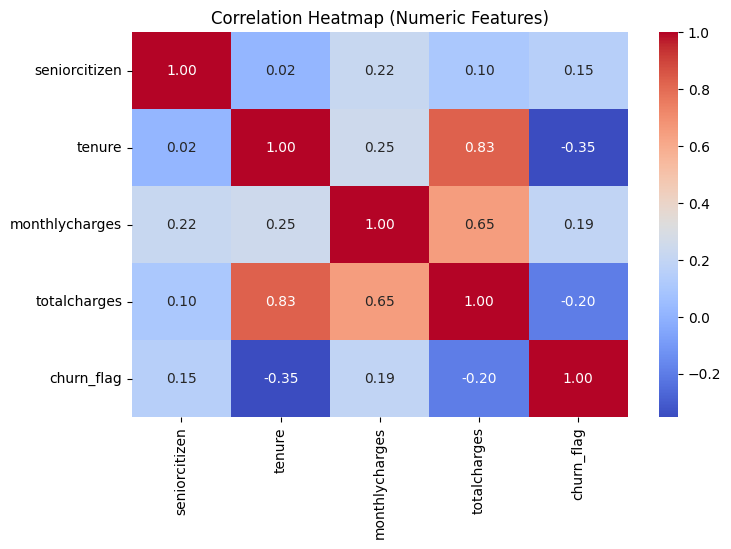

In [43]:
num_cols = [
    "seniorcitizen",
    "tenure",
    "monthlycharges",
    "totalcharges",
    "churn_flag"
]

corr = telco_churn[num_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


The correlation heatmap highlights several important relationships between numeric variables and customer churn.

Tenure shows the strongest relationship with churn, exhibiting a moderate negative correlation (-0.35). This indicates that customers who have been with the company longer are significantly less likely to churn, reinforcing tenure as a key stability and loyalty indicator.

Monthly charges display a positive correlation with churn (0.19), suggesting that higher recurring costs increase the likelihood of customer churn. This aligns with earlier EDA findings showing higher churn among customers with higher monthly fees.

Total charges are negatively correlated with churn (-0.20). Since total charges accumulate over time, this relationship reflects the indirect effect of tenure—customers who remain longer generate higher total charges and are less likely to churn.

Senior citizen status has a weak positive correlation with churn (0.15), indicating a slightly higher churn tendency among senior customers, though the relationship is less pronounced compared to tenure and pricing variables.

Finally, strong correlations between tenure and total charges (0.83) and between monthly charges and total charges (0.65) confirm expected structural relationships within the data.